
==================== Analysis: Stage 1 (1-9 Reviews) ====================


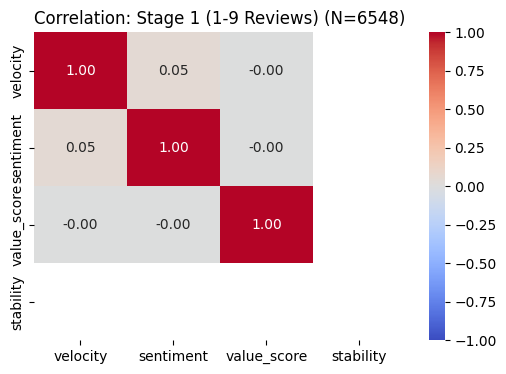

[Stage 1 (1-9 Reviews) VIF Score]
  Signal_Indicator  VIF_Score
0         velocity    1.00246
1        sentiment    1.00244
2      value_score    1.00002
3        stability        NaN

==================== Analysis: Stage 2 (10-49 Reviews) ====================


c:\Users\asdxo\Desktop\sparta_pj4\steam-indie-game-analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


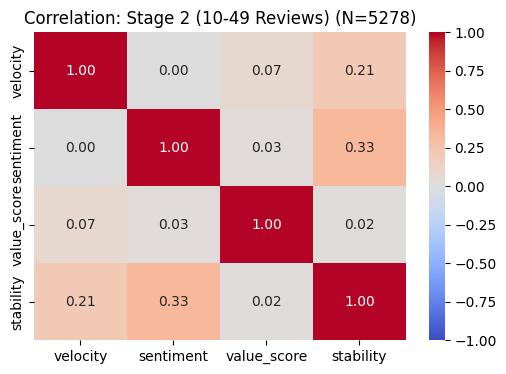

[Stage 2 (10-49 Reviews) VIF Score]
  Signal_Indicator  VIF_Score
3        stability   1.185926
1        sentiment   1.132630
0         velocity   1.058597
2      value_score   1.005832

==================== Analysis: Global (Excluding Stage 1) ====================


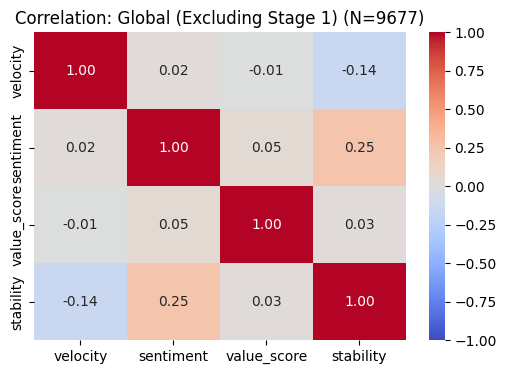

[Global (Excluding Stage 1) VIF Score]
  Signal_Indicator  VIF_Score
3        stability   1.095755
1        sentiment   1.075184
0         velocity   1.025629
2      value_score   1.002685

==================== Signal Comparison Summary ====================
                velocity  sentiment  value_score  stability
Stage 1         3.868968   0.117466     0.017868   0.000000
Stage 2        22.493748  84.152953     0.718646  34.313776
Global (S2+)  797.099928  84.146517    39.247862  35.625181


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

base_path = '../../../../data/preprocessed/'
df_graded = pd.read_csv(f'{base_path}steam_indie_games_graded.csv')
df_silence = pd.read_csv(f'{base_path}steam_indie_games_silence.csv') 
hist_df = pd.read_csv(f'{base_path}steam_indie_review_histogram.csv')

df = pd.concat([df_graded, df_silence], ignore_index=True)
df = df[df['total_reviews'] > 0].copy()

def assign_stage(rev_count):
    if 1 <= rev_count <= 9: return 1
    elif 10 <= rev_count <= 49: return 2
    elif 50 <= rev_count <= 499: return 3
    else: return 4

df['stage'] = df['total_reviews'].apply(assign_stage)

hist_df['daily_pos_rate'] = (hist_df['recommendations_up'] / 
                            (hist_df['recommendations_up'] + hist_df['recommendations_down'] + 1e-6)) * 100
stability_df = hist_df.groupby('appid')['daily_pos_rate'].std().reset_index(name='stability')

df = pd.merge(df, stability_df, on='appid', how='left')

df['velocity'] = df['total_reviews']
df['sentiment'] = df['positive_rate'].fillna(0)
df['recommendations_total'] = df['recommendations_total'].fillna(0)
df['value_score'] = df['recommendations_total'] / (df['owners_lower'] + 1)
df['stability'] = df['stability'].fillna(0)

def run_signal_analysis(data, group_name):
    print(f"\n{'='*20} Analysis: {group_name} {'='*20}")
    signal_columns = ['velocity', 'sentiment', 'value_score', 'stability']
    analysis_df = data[signal_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
    
    if len(analysis_df) < 2:
        print("Insufficient data.")
        return

    plt.figure(figsize=(6, 4))
    sns.heatmap(analysis_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f'Correlation: {group_name} (N={len(analysis_df)})')
    plt.show()

    analysis_df_vif = analysis_df.copy()
    analysis_df_vif['const'] = 1 
    vif_data = pd.DataFrame()
    vif_data["Signal_Indicator"] = analysis_df_vif.columns
    vif_data["VIF_Score"] = [variance_inflation_factor(analysis_df_vif.values, i) 
                             for i in range(analysis_df_vif.shape[1])]

    print(f"[{group_name} VIF Score]")
    print(vif_data[vif_data['Signal_Indicator'] != 'const'].sort_values(by="VIF_Score", ascending=False))

run_signal_analysis(df[df['stage'] == 1], "Stage 1 (1-9 Reviews)")
run_signal_analysis(df[df['stage'] == 2], "Stage 2 (10-49 Reviews)")
run_signal_analysis(df[df['stage'] >= 2], "Global (Excluding Stage 1)")

print(f"\n{'='*20} Signal Comparison Summary {'='*20}")
group_means = pd.DataFrame({
    'Stage 1': df[df['stage'] == 1][['velocity', 'sentiment', 'value_score', 'stability']].mean(),
    'Stage 2': df[df['stage'] == 2][['velocity', 'sentiment', 'value_score', 'stability']].mean(),
    'Global (S2+)': df[df['stage'] >= 2][['velocity', 'sentiment', 'value_score', 'stability']].mean()
}).T

print(group_means)

에러 안뜨게 수정


==================== Analysis: Stage 1 (1-9 Reviews) ====================


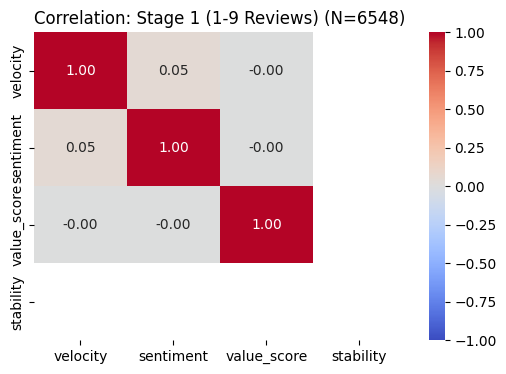

Skipping constant columns for VIF: ['stability']
[Stage 1 (1-9 Reviews) VIF Score]
  Signal_Indicator  VIF_Score
0         velocity    1.00246
1        sentiment    1.00244
2      value_score    1.00002

==================== Analysis: Stage 2 (10-49 Reviews) ====================


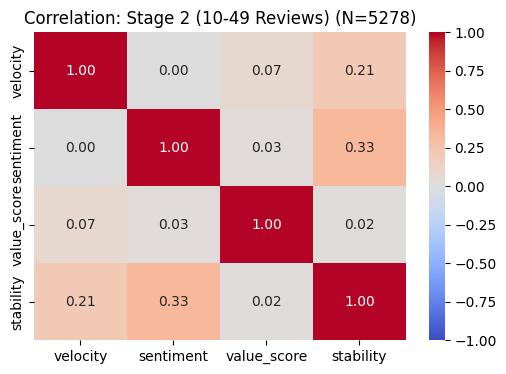

[Stage 2 (10-49 Reviews) VIF Score]
  Signal_Indicator  VIF_Score
3        stability   1.185926
1        sentiment   1.132630
0         velocity   1.058597
2      value_score   1.005832

==================== Analysis: Global (Excluding Stage 1) ====================


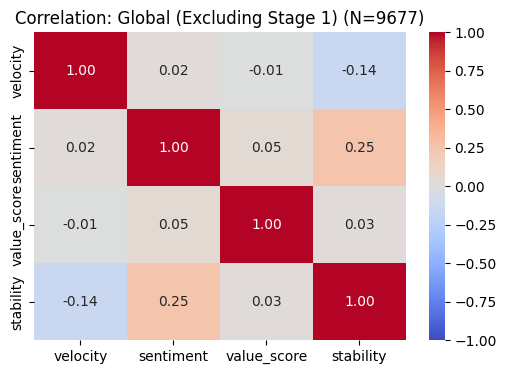

[Global (Excluding Stage 1) VIF Score]
  Signal_Indicator  VIF_Score
3        stability   1.095755
1        sentiment   1.075184
0         velocity   1.025629
2      value_score   1.002685

==================== Signal Comparison Summary ====================
                velocity  sentiment  value_score  stability
Stage 1         3.868968   0.117466     0.017868   0.000000
Stage 2        22.493748  84.152953     0.718646  34.313776
Global (S2+)  797.099928  84.146517    39.247862  35.625181


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

base_path = '../../../../data/preprocessed/'
df_graded = pd.read_csv(f'{base_path}steam_indie_games_graded.csv')
df_silence = pd.read_csv(f'{base_path}steam_indie_games_silence.csv') 
hist_df = pd.read_csv(f'{base_path}steam_indie_review_histogram.csv')

df = pd.concat([df_graded, df_silence], ignore_index=True)
df = df[df['total_reviews'] > 0].copy()

def assign_stage(rev_count):
    if 1 <= rev_count <= 9: return 1
    elif 10 <= rev_count <= 49: return 2
    elif 50 <= rev_count <= 499: return 3
    else: return 4

df['stage'] = df['total_reviews'].apply(assign_stage)

hist_df['daily_pos_rate'] = (hist_df['recommendations_up'] / 
                            (hist_df['recommendations_up'] + hist_df['recommendations_down'] + 1e-6)) * 100
stability_df = hist_df.groupby('appid')['daily_pos_rate'].std().reset_index(name='stability')

df = pd.merge(df, stability_df, on='appid', how='left')

df['velocity'] = df['total_reviews']
df['sentiment'] = df['positive_rate'].fillna(0)
df['recommendations_total'] = df['recommendations_total'].fillna(0)
df['value_score'] = df['recommendations_total'] / (df['owners_lower'] + 1)
df['stability'] = df['stability'].fillna(0)

def run_signal_analysis(data, group_name):
    print(f"\n{'='*20} Analysis: {group_name} {'='*20}")
    signal_columns = ['velocity', 'sentiment', 'value_score', 'stability']
    analysis_df = data[signal_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
    
    if len(analysis_df) < 2:
        print("Insufficient data.")
        return

    plt.figure(figsize=(6, 4))
    sns.heatmap(analysis_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f'Correlation: {group_name} (N={len(analysis_df)})')
    plt.show()

    vif_df = analysis_df.copy()
    constant_cols = [col for col in vif_df.columns if vif_df[col].nunique() <= 1]
    if constant_cols:
        print(f"Skipping constant columns for VIF: {constant_cols}")
        vif_df = vif_df.drop(columns=constant_cols)

    if not vif_df.empty:
        vif_df['const'] = 1 
        vif_data = pd.DataFrame()
        vif_data["Signal_Indicator"] = vif_df.columns
        vif_data["VIF_Score"] = [variance_inflation_factor(vif_df.values, i) 
                                 for i in range(vif_df.shape[1])]
        print(f"[{group_name} VIF Score]")
        print(vif_data[vif_data['Signal_Indicator'] != 'const'].sort_values(by="VIF_Score", ascending=False))
    else:
        print("No variance in data to calculate VIF.")

run_signal_analysis(df[df['stage'] == 1], "Stage 1 (1-9 Reviews)")
run_signal_analysis(df[df['stage'] == 2], "Stage 2 (10-49 Reviews)")
run_signal_analysis(df[df['stage'] >= 2], "Global (Excluding Stage 1)")

print(f"\n{'='*20} Signal Comparison Summary {'='*20}")
group_means = pd.DataFrame({
    'Stage 1': df[df['stage'] == 1][['velocity', 'sentiment', 'value_score', 'stability']].mean(),
    'Stage 2': df[df['stage'] == 2][['velocity', 'sentiment', 'value_score', 'stability']].mean(),
    'Global (S2+)': df[df['stage'] >= 2][['velocity', 'sentiment', 'value_score', 'stability']].mean()
}).T

print(group_means)